In [1]:
from mainnet_launch.pages.asset_discounts.stable_coin_pricing import (
    StableCoinConsants,
    stablecoin_constants,
    build_balancer_query_swap_call,
)
from mainnet_launch.data_fetching.get_state_by_block import (
    get_raw_state_by_blocks,
    get_state_by_one_block,
    build_blocks_to_use,
    _build_blocks_to_use_dont_clip,
)
from mainnet_launch.constants import ETH_CHAIN
import plotly.express as px
import plotly.io as pio
import pandas as pd

pio.templates.default = None
# token_symbols = [c.symbol for c in stablecoin_constants if c.symbol not in ["sUSDs", "USDs"]]

blocks = build_blocks_to_use(ETH_CHAIN, start_block=20689810)


def build_stable_coin_safe_prices(stablecoin_constants: list[StableCoinConsants], blocks: list[int]) -> pd.DataFrame:
    backing_calls = [c.backing_call for c in stablecoin_constants]
    safe_price_calls = [c.safe_price_call for c in stablecoin_constants if c.safe_price_call is not None]
    df = get_raw_state_by_blocks([*backing_calls, *safe_price_calls], blocks, ETH_CHAIN, include_block_number=True)
    df["sUSDs_safe_price"] = df["sUSDs_backing"] * df["USDs_safe_price"]
    df["scrvUSD_safe_price"] = df["scrvUSD_backing"] * df["crvUSD_safe_price"]
    df["sUSDe_safe_price"] = df["sUSDe_backing"] * df["USDe_safe_price"]
    return df


def build_stable_coin_spot_price(stablecoin_constants: list[StableCoinConsants], blocks: list[int]) -> pd.DataFrame:
    spot_price_calls = [
        call
        for calls in [c.spot_price_calls for c in stablecoin_constants if c.spot_price_calls is not None]
        for call in calls
    ]

    backing_calls = [c.backing_call for c in stablecoin_constants]

    safe_price_calls = [c.safe_price_call for c in stablecoin_constants if c.safe_price_call is not None]

    df = get_raw_state_by_blocks(
        [*backing_calls, *safe_price_calls, *spot_price_calls], blocks, ETH_CHAIN, include_block_number=True
    )

    df["sUSDs_safe_price"] = df["sUSDs_backing"] * df["USDs_safe_price"]
    df["scrvUSD_safe_price"] = df["scrvUSD_backing"] * df["crvUSD_safe_price"]
    df["sUSDe_safe_price"] = df["sUSDe_backing"] * df["USDe_safe_price"]

    # df['USDe_to_USDC_spot_price_2'] = df['sUSDs_to_USDC_spot_price'] / df['sUSDs_backing']

    # df["USDs_spot_price"] = -1.0 # add in later
    # df["sUSDs_spot_price"] = -1.0 # add in later

    return df


df = build_stable_coin_spot_price(stablecoin_constants, blocks)
df

[Errno 1] [SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2548) [0]
[Errno 1] [SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2548) [0]


,DAI_backing,USDe_backing,USDC_backing,USDT_backing,USDs_backing,GHO_backing,crvUSD_backing,FRAX_backing,scrvUSD_backing,sUSDe_backing,...,GHO_to_USDC_spot_price,GHO_to_crvUSD_spot_price,crvUSD_to_USDC_spot_price,crvUSD_to_USDT_spot_price,FRAX_to_USDe_spot_price,sFRAX_to_crvUSD_spot_price,block,sUSDs_safe_price,scrvUSD_safe_price,sUSDe_safe_price
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-09-15 23:38:59+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.100863,...,1.005566,0.992227,0.999045,0.998733,1.001831,0.997965,20759360,NaN,NaN,1.099872
2024-09-16 23:48:35+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.101001,...,1.005473,0.993366,0.998953,0.999045,1.001690,0.998107,20766560,NaN,NaN,1.099900
2024-09-17 23:59:47+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.101140,...,1.006479,0.991808,0.998833,0.998660,1.001741,0.998055,20773760,NaN,NaN,1.099834
2024-09-18 23:38:47+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.101275,...,1.005301,0.993024,0.998607,0.998551,1.001741,0.998055,20780810,NaN,NaN,1.100086
2024-09-19 23:45:11+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.101424,...,1.001958,0.996030,0.998215,0.998122,1.001765,0.998031,20788010,NaN,NaN,1.100089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-11 23:49:11+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.041686,1.162112,...,0.999148,0.999876,0.999612,0.999844,1.001111,0.998687,22027010,1.042655,1.041346,1.161515
2025-03-12 23:57:11+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.041701,1.162270,...,0.999290,1.000052,0.999710,0.999911,1.000959,0.998840,22034210,1.042893,1.041814,1.161438
2025-03-13 23:33:23+00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.041728,1.162424,...,0.999377,0.999741,0.999630,1.000009,1.000962,0.998836,22041260,1.042887,1.041360,1.161993


In [2]:
df.columns

Index(['DAI_backing', 'USDe_backing', 'USDC_backing', 'USDT_backing',
       'USDs_backing', 'GHO_backing', 'crvUSD_backing', 'FRAX_backing',
       'scrvUSD_backing', 'sUSDe_backing', 'sUSDs_backing', 'sFRAX_backing',
       'DAI_safe_price', 'USDe_safe_price', 'USDC_safe_price',
       'USDT_safe_price', 'USDs_safe_price', 'GHO_safe_price',
       'crvUSD_safe_price', 'FRAX_safe_price', 'DAI_to_USDC_spot_price',
       'DAI_to_USDC_spot_price2', 'USDe_to_USDC_spot_price',
       'sUSDe_to_USDC_spot_price', 'USDC_to_USDC_spot_price',
       'USDC_to_USDC_spot_price_2', 'USDT_to_USDC_spot_price',
       'USDT_to_USDC_spot_price2', 'sUSD_to_USDC_spot_price',
       'sUSD_to_USDC_spot_price_via_peg', 'GHO_to_USDC_spot_price',
       'GHO_to_crvUSD_spot_price', 'crvUSD_to_USDC_spot_price',
       'crvUSD_to_USDT_spot_price', 'FRAX_to_USDe_spot_price',
       'sFRAX_to_crvUSD_spot_price', 'block', 'sUSDs_safe_price',
       'scrvUSD_safe_price', 'sUSDe_safe_price'],
      dtype='object')

In [6]:
def _extract_spot_prices(main_df: pd.DataFrame):
    df = main_df.copy()

    # USDC
    df["USDC_spot_price"] = 1.0

    # USDT
    df["USDT_spot_price"] = df[["USDT_to_USDC_spot_price", "USDT_to_USDC_spot_price2"]].max(axis=1)

    # DAI
    df["DAI_spot_price"] = df[["DAI_to_USDC_spot_price", "DAI_to_USDC_spot_price2"]].max(axis=1)

    # USDe and sUSDe
    df["USDe_to_USDC_spot_price2"] = df["sUSDe_to_USDC_spot_price"].div(df["sUSDe_backing"])
    df["USDe_spot_price"] = df[["USDe_to_USDC_spot_price", "USDe_to_USDC_spot_price2"]].max(axis=1)
    df["sUSDe_spot_price"] = df["USDe_spot_price"] * df["sUSDe_backing"]

    # crvUSD, scrvUSD
    df["crvUSD_to_USDC_spot_price2"] = df["crvUSD_to_USDT_spot_price"] * df["USDT_safe_price"]

    df["crvUSD_spot_price"] = df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDC_spot_price2"]].max(axis=1)
    df["scrvUSD_spot_price"] = df["crvUSD_spot_price"] * df["scrvUSD_backing"]

    # USDs and sUSDs is a special case
    df["sUSDs_to_USDC_spot_price"] = df["sUSDS_to_FRAX_spot_price"] * df["FRAX_safe_price"]
    df["sUSD_to_USDC_spot_price2"] = df["sUSDs_to_USDC_spot_price"].div(df["sUSDs_backing"])

    df["sUSD_spot_price"] = df[["sUSD_to_USDC_spot_price", "sUSD_to_USDC_spot_price2"]].max(axis=1)
    df["sUSDs_spot_price"] = df["sUSD_spot_price"] * df["sUSDs_backing"]

    # GHO
    df["GHO_to_USDC_spot_price2"] = df["GHO_to_crvUSD_spot_price"] * df["crvUSD_safe_price"]
    df["GHO_spot_price"] = df[["GHO_to_USDC_spot_price", "GHO_to_USDC_spot_price2"]].max(axis=1)

    # FRAX and sFRAX
    df["sFRAX_to_USDC_spot_price"] = df["sFRAX_to_crvUSD_spot_price"] * df["crvUSD_safe_price"]
    df["FRAX_to_USDC_spot_price"] = df["sFRAX_to_USDC_spot_price"].div(df["sFRAX_backing"])
    df["FRAX_to_USDC_spot_price2"] = df["FRAX_to_USDe_spot_price"] * df["USDe_safe_price"]

    df["FRAX_spot_price"] = df[["FRAX_to_USDC_spot_price", "FRAX_to_USDC_spot_price2"]].max(axis=1)
    df["sFRAX_spot_price"] = df["FRAX_spot_price"] * df["sFRAX_backing"]

    return df[
        [
            "USDC_spot_price",
            "DAI_spot_price",
            "USDe_spot_price",
            "sUSDe_spot_price",
            "crvUSD_spot_price",
            "scrvUSD_spot_price",
            "sUSD_spot_price",
            "sUSDs_spot_price",
            "GHO_spot_price",
            "FRAX_spot_price",
            "sFRAX_spot_price",
        ]
    ].copy()


spot_prices = _extract_spot_prices(df)
px.line(spot_prices)

In [ ]:
# I think there is a peg stability module for USDS and USDC on mainnet
#

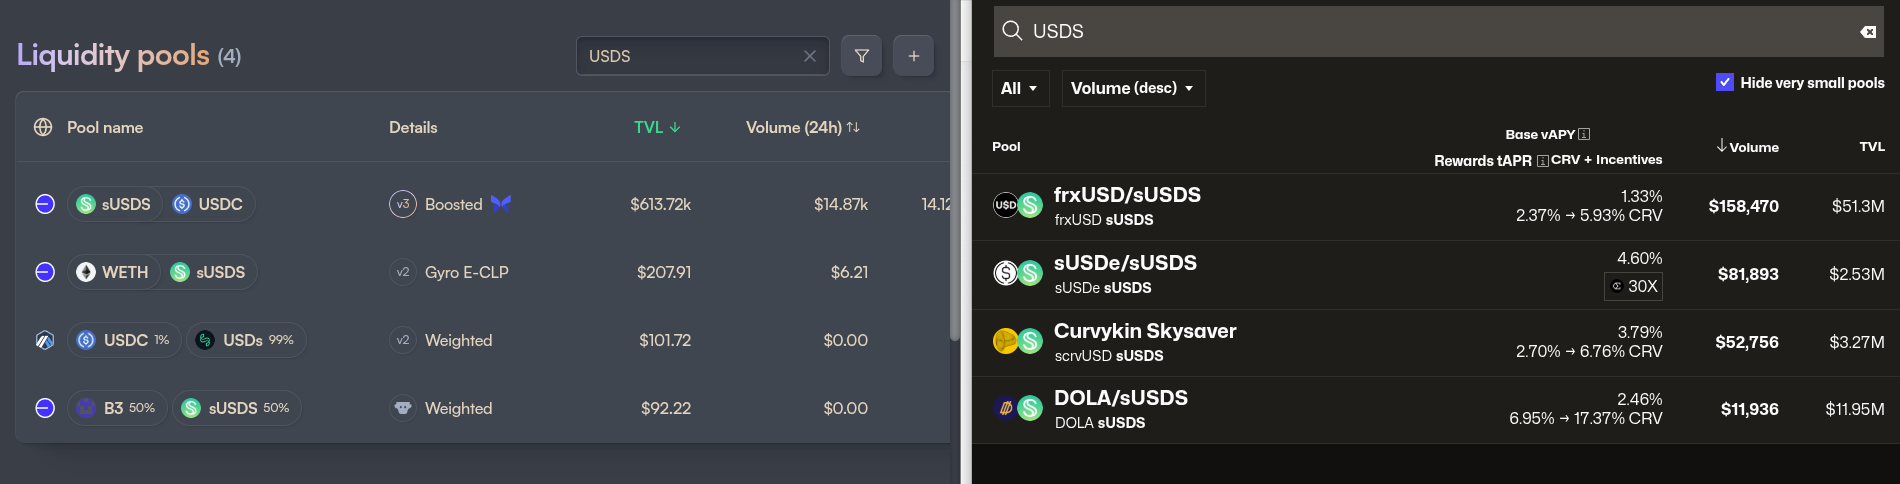

There is no liqudity for USDS on curve or balancer

In [ ]:
# frxETH/sUSDs started on feb 19 days old https://etherscan.io/tx/0x1337bb704ce15d22664b646855a4b3c7ff484ca79f34de0cea16f04190e54e0e

In [ ]:
df.columns

Index(['DAI_backing', 'USDe_backing', 'USDC_backing', 'USDT_backing',
       'USDs_backing', 'GHO_backing', 'crvUSD_backing', 'FRAX_backing',
       'scrvUSD_backing', 'sUSDe_backing', 'sUSDs_backing', 'sFRAX_backing',
       'DAI_safe_price', 'USDe_safe_price', 'USDC_safe_price',
       'USDT_safe_price', 'USDs_safe_price', 'GHO_safe_price',
       'crvUSD_safe_price', 'FRAX_safe_price', 'DAI_to_USDC_spot_price',
       'DAI_to_USDC_spot_price2', 'USDe_to_USDC_spot_price',
       'sUSDe_to_USDC_spot_price', 'USDC_to_USDC_spot_price',
       'USDC_to_USDC_spot_price_2', 'USDT_to_USDC_spot_price',
       'USDT_to_USDC_spot_price2', 'sUSD_to_USDC_spot_price',
       'sUSD_to_USDC_spot_price_via_peg', 'GHO_to_USDC_spot_price',
       'GHO_to_crvUSD_spot_price', 'crvUSD_to_USDC_spot_price',
       'crvUSD_to_USDT_spot_price', 'FRAX_to_USDe_spot_price',
       'sFRAX_to_crvUSD_spot_price', 'block', 'sUSDs_safe_price',
       'scrvUSD_safe_price', 'sUSDe_safe_price'],
      dtype='object')

In [ ]:
def _extract_safe_prices_df(df: pd.DataFrame):
    safe_price_cols = [col for col in df.columns if "safe_price" in col]
    safe_price_tokens = [t.split("_")[0] for t in safe_price_cols]
    safe_price_df = df[safe_price_cols].copy()
    safe_price_df.columns = safe_price_tokens
    return safe_price_df


safe_price_df = _extract_safe_prices_df(df.iloc[10:])
px.line(safe_price_df)

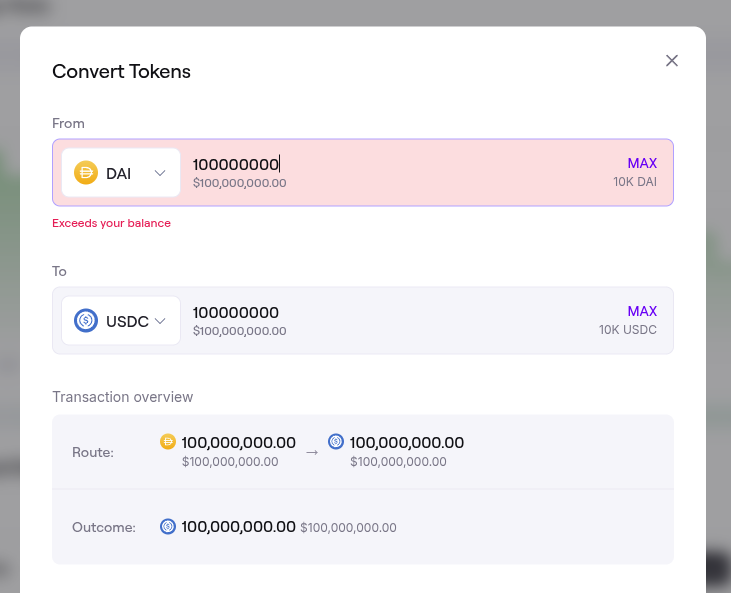

100M DAI for USDC

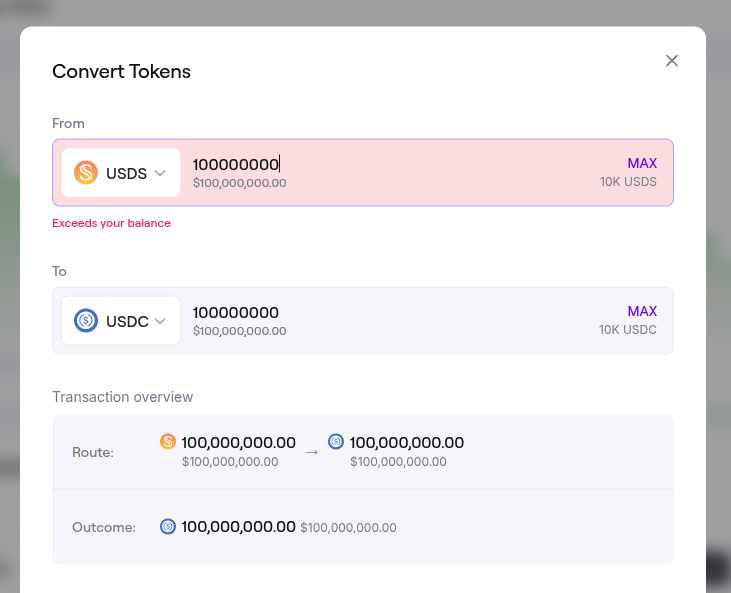
100M DAI for USDC on mainnet at no slippage

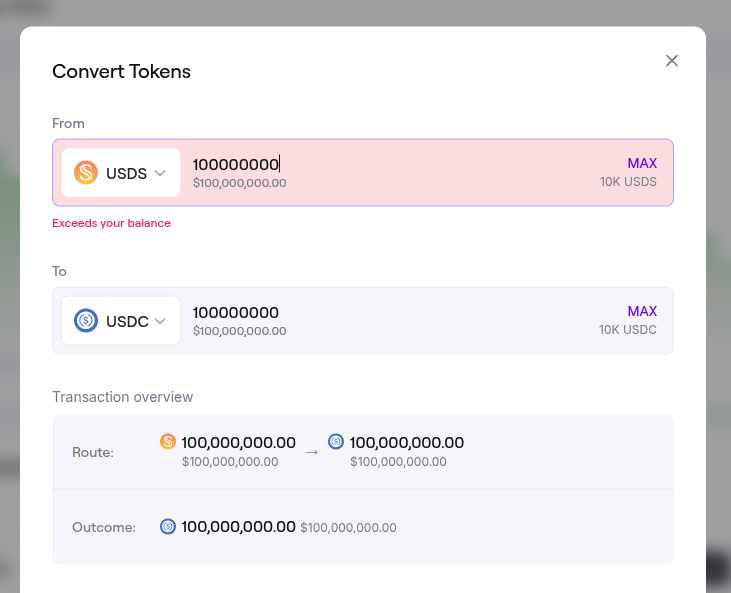

100M USDS for USDC on mainnet at no slippage

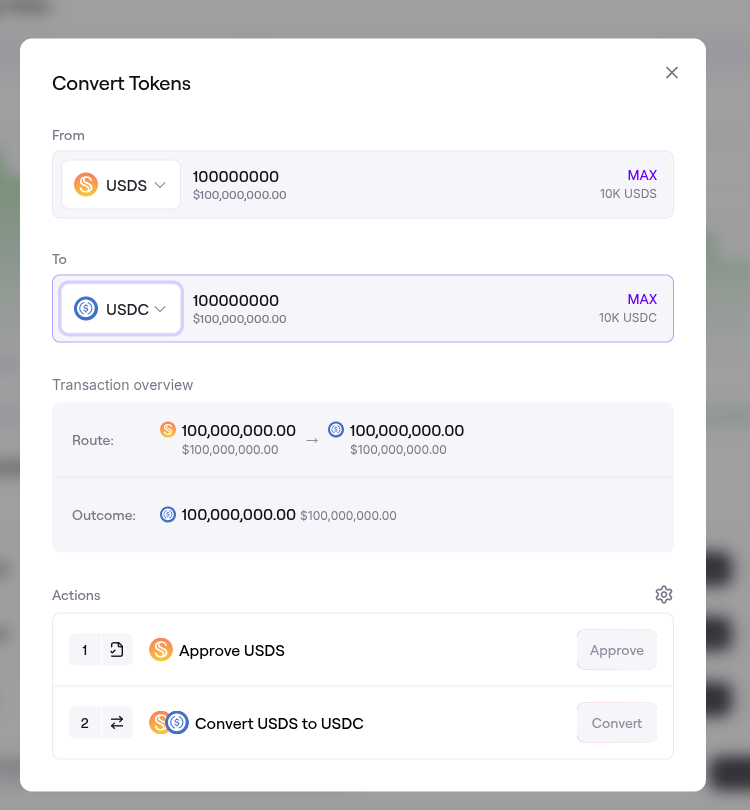

In [ ]:
safe_price_df[["USDC", "DAI", "USDs"]].head(10)

,USDC,DAI,USDs
timestamp,,,
2024-09-25 23:59:59+00:00,0.999960,0.999909,1.008149
2024-09-26 23:35:47+00:00,0.999900,1.000045,1.008149
2024-09-27 23:40:59+00:00,0.999940,0.999999,1.019258
2024-09-28 23:47:23+00:00,0.999940,0.999748,1.018505
2024-09-29 23:53:59+00:00,0.999941,0.999788,1.002945
2024-09-30 23:58:23+00:00,0.999930,0.999621,1.000739
2024-10-01 23:34:59+00:00,0.999893,1.000203,0.998980
2024-10-02 23:39:47+00:00,0.999960,0.999939,0.997791
2024-10-03 23:46:59+00:00,0.999941,0.999815,0.998176


In [ ]:
# understand the peg stablity module for this pool
# it seems like we use the 1:1 route 99% of the time, since getting .9999 DAI for each USDC
#

# DAI -> USDC, compare the curve pool and the PSM


# Codebase

# Deployment Addresses

# Details

# Converts DAI to USDS at a fixed ratio of 1:1 and vice versa.

# No fees assessed.

# Fees cannot be enabled on this route in the future.


# https://etherscan.io/address/0x3225737a9Bbb6473CB4a45b7244ACa2BeFdB276A


# It's all about DAI:USDs

In [ ]:
# I think AAVE used USDs: DAI price feed
@#https://governance.aave.com/t/technical-maintenance-proposals/15274/45

SyntaxError: invalid syntax (1203437553.py, line 2)

In [ ]:
px.line(safe_price_df)

In [ ]:
impor

In [ ]:
# Ethena owns a lot of sUSDs
# 0x2d4d2a025b10c09bdbd794b4fce4f7ea8c7d7bb4

# https://etherscan.io/address/0x7f311a4d48377030bd810395f4ccfc03bdbe9ef3#code

In [ ]:
# This is a special case. check the transfer volumne of DAI vs all the others

In [ ]:
sp

In [ ]:
def build_

In [ ]:
px.line(spot_price_df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDT_spot_price"]])

NameError: name 'spot_price_df' is not defined

In [ ]:
# def fetch_stable_coin_spot_safe_and_backing():

#     # # 100 * (peg - safe) / peg
#     # for symbol in token_symbols:
#     #     df[f"{symbol}_discount"] = 100 * ((df[f"{symbol}_backing"] - df[f"{symbol}_safe_price"]) / df[f"{symbol}_backing"])

#     discount_cols = [c for c in df.columns if "_discount" in c]
#     px.line(df[discount_cols], title="stablecoin percent discoutns")

#     spot_price_calls = [
#         call
#         for calls in [c.spot_price_calls for c in stablecoin_constants if c.spot_price_calls is not None]
#         for call in calls
#     ]
#     spot_price_df = get_raw_state_by_blocks(spot_price_calls, blocks, ETH_CHAIN)
#     full_df = pd.concat([df, spot_price_df], axis=1)

#     full_df["DAI_spot_price"] = full_df[["DAI_to_USDC_spot_price", "DAI_to_USDC_spot_price2"]].max(axis=1)
#     full_df["USDs_spot_price"] = full_df["DAI_spot_price"]  # dai is 1:1 with USDs

#     full_df["USDe_to_USDC_spot_price2"] = full_df["sUSEe_to_USDC_spot_price"].divide(full_df["sUSDe_backing"])
#     full_df["USDe_spot_price"] = full_df[["USDe_to_USDC_spot_price", "USDe_to_USDC_spot_price2"]].max(axis=1)

#     full_df["USDC_spot_price"] = 1.0  # by definition

#     full_df["USDT_spot_price"] = full_df[["USDT_to_USDC_spot_price", "USDT_to_USDC_spot_price2"]].max(axis=1)
#     full_df["GHO_spot_price"] = full_df[["GHO_to_USDC_spot_price"]].max(axis=1)
#     full_df["crvUSD_to_USDC_spot_price2"] = full_df["crvUSD_to_USDT_spot_price"] * full_df["USDT_spot_price"]

#     full_df["crvUSD_spot_price"] = full_df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDC_spot_price2"]].max(axis=1)

#     full_df["scrvUSD_spot_price"] = full_df["crvUSD_spot_price"] * full_df["scrvUSD_backing"]
#     full_df["sUSDe_spot_price"] = full_df["USDe_spot_price"] * full_df["sUSDe_backing"]

#     return full_df


# df = fetch_stable_coin_spot_safe_and_backing()

# df

In [ ]:
safe_price_cols = [f"{t}_safe_price" for t in token_symbols]
backing_cols = [f"{t}_backing" for t in token_symbols]
spot_price_cols = [f"{t}_spot_price" for t in token_symbols]
df[[*spot_price_cols, *spot_price_cols, *backing_cols]].to_csv("stable_coin_prices.csv")

percent_difference_from_peg_in_safe = pd.DataFrame(
    data=100 * (df[backing_cols].values - df[safe_price_cols].values) / (df[backing_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_from_peg_in_safe.to_csv("percent_difference_from_peg_in_safe.csv")

percent_difference_between_safe_and_spot = pd.DataFrame(
    data=100 * (df[safe_price_cols].values - df[spot_price_cols].values) / (df[safe_price_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_between_safe_and_spot.to_csv("percent_difference_between_safe_and_spot.csv")

percent_difference_from_peg_in_spot = pd.DataFrame(
    data=100 * (df[backing_cols].values - df[spot_price_cols].values) / (df[backing_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_from_peg_in_spot.to_csv("percent_difference_from_peg_in_spot.csv")

px.line(percent_difference_from_peg_in_spot, title="100 * (backing - spot_price) / backing").show()
px.line(percent_difference_from_peg_in_safe, title="100 * (backing - safe price) / backing").show()
px.line(percent_difference_between_safe_and_spot, title="100 * (safe price - spot_price) / spot price").show()

In [ ]:
px.ecdf(percent_difference_from_peg_in_spot, title="100 * (backing - spot_price) / backing").show()
px.ecdf(percent_difference_from_peg_in_safe, title="100 * (backing - safe price) / backing").show()
px.ecdf(percent_difference_between_safe_and_spot, title="100 * (safe price - spot_price) / spot price").show()

In [ ]:
percent_difference_between_safe_and_spot.describe(percentiles=[0.2, 0.8]).T.round(4) * 100

In [ ]:
px.ecdf(percent_difference_between_safe_and_spot)

In [ ]:
from mainnet_launch.constants import ETH_CHAIN, ROOT_PRICE_ORACLE

from multicall import Call

from mainnet_launch.data_fetching.get_state_by_block import (
    safe_normalize_6_with_bool_success,
    safe_normalize_with_bool_success,
)

USDC = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48"


def build_root_price_oracle_to_USDC_call(token_address: str, name: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE(ETH_CHAIN),
        ["getPriceInQuote(address,address)(uint256)", ETH_CHAIN.client.toChecksumAddress(token_address), USDC],
        [(name, safe_normalize_6_with_bool_success)],
    )


calls = [
    build_root_price_oracle_to_USDC_call(c.token_address, f"{c.token_address} {c.symbol}") for c in stablecoin_constants
]
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
# DAI, USDC

In [ ]:
def build_get_price_in_eth_call(token_address: str, name: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE(ETH_CHAIN),
        ["getPriceInQuote(address,address)(uint256)", ETH_CHAIN.client.toChecksumAddress(token_address), USDC],
        [(name, safe_normalize_6_with_bool_success)],
    )


calls = [
    build_root_price_oracle_to_USDC_call(c.token_address, f"{c.token_address} {c.symbol}") for c in stablecoin_constants
]
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
# RootPriceOracle.getPriceInQuote(base, quote) -> uses chainlink

In [ ]:
ROOT_PRICE_ORACLE(ETH_CHAIN), USDC

In [ ]:
blocks = build_blocks_to_use(ETH_CHAIN)

In [ ]:
import numpy as numpy

numpy.median(blocks)

In [ ]:
get_state_by_one_block(calls, 21400535, ETH_CHAIN)  # Dec 14th

In [ ]:
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
stablecoin_constants

In [ ]:
ROOT_PRICE_ORACLE(ETH_CHAIN)

In [ ]:
pass

In [ ]:
DAI_to_USDC_spot_price = Call(
    "0xbEbc44782C7dB0a1A60Cb6fe97d0b483032FF1C7",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("DAI_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)

DAI_to_USDC_spot_price2 = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("DAI_to_USDC_spot_price2", safe_normalize_6_with_bool_success)],
)


USDT_to_USDC_spot_price = Call(
    "0xbEbc44782C7dB0a1A60Cb6fe97d0b483032FF1C7",
    ["get_dy(int128,int128,uint256)(uint256)", 2, 1, int(1e6)],
    [("USDT_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)

USDT_to_USDC_spot_price_2 = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 2, 1, int(168)],
    [("USDT_to_USDC_spot_price_2", safe_normalize_6_with_bool_success)],
)


crvUSD_to_USDC_spot_price = Call(
    "0x4DEcE678ceceb27446b35C672dC7d61F30bAD69E",
    ["get_dy(int128,int128,uint256)(uint256)", 1, 0, int(1e18)],
    [("crvUSD_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


crvUSD_to_USDT_spot_price = Call(
    "0x390f3595bCa2Df7d23783dFd126427CCeb997BF4",
    ["get_dy(int128,int128,uint256)(uint256)", 1, 0, int(1e18)],
    [("crvUSD_to_USDT_spot_price", safe_normalize_6_with_bool_success)],
)


USDe_to_USDC_spot_price = Call(
    "0x02950460E2b9529D0E00284A5fA2d7bDF3fA4d72",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("USDe_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


sUSD_to_USDC_spot_price = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 3, 1, int(1e18)],
    [("sUSD_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


# balancer GHO -> USDC
# https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9

# https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9
# USDT, GHO, USDC


calls = [
    crvUSD_to_USDC_spot_price,
    USDe_to_USDC_spot_price,
    DAI_to_USDC_spot_price,
    USDT_to_USDC_spot_price,
]

get_state_by_one_block(calls, max(blocks), ETH_CHAIN)

In [ ]:
# s  # sUSDe -> usdc https://balancer.fi/pools/ethereum/v2/0xb819feef8f0fcdc268afe14162983a69f6bf179e000000000000000000000689

# gho, USDC, USDT tri pool  https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9

# https://curve.fi/dex/ethereum/pools/factory-crvusd-0/deposit/
# crvUSD -> USDC


# dai, USDC, USDT tri pool
# https://curve.fi/dex/ethereum/pools/3pool/deposit/

# USDe -> USDC https://curve.fi/dex/ethereum/pools/factory-stable-ng-12/deposit/

# USDs does not have good sorces of liquidty


# https://app.uniswap.org/explore/pools/ethereum/0x5777d92f208679DB4b9778590Fa3CAB3aC9e2168

In [ ]:
# from web3 import Web3

# # Assume you have an initialized Web3 instance (e.g. using an Infura or Alchemy endpoint)

# queries_address = Web3.toChecksumAddress("0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5")

# pool_id = bytes.fromhex("0xb819feef8f0fcdc268afe14162983a69f6bf179e000000000000000000000689"[2:])
# amount_in = int(1e18)
# swap_kind = 0
# user_data = b""

# from_internal_balance = False
# to_internal_balance = False

# call_obj = Call(
#     "0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5",  # Balancer Queries contract address
#     [
#         # Function signature for querySwap with two tuple parameters:
#         "querySwap((bytes32,uint8,address,address,uint256,bytes),(address,bool,address,bool))(uint256)",
#         pool_id,
#         swap_kind,
#         sUSDe,
#         USDC,
#         amount_in,
#         user_data,
#         '0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5',
#         from_internal_balance,
#         '0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5',
#         to_internal_balance
#     ]
#     [("usdc_out", safe_normalize_6_with_bool_success)]
# )

# get_state_by_one_block([call_obj],22027082, ETH_CHAIN )